# FinTrust Digital Bank — Week 2 Python Exploratory Data Analysis
**Data Analytics Track | Part C**



**Source data:** the *cleaned* datasets produced in Part A (`customer_clean.csv`, `transaction_clean.csv`)
- The missing `Device_Type`/`Location` filled as `'Unknown'`,
-  `Transaction_DateTime` converted to a real datetime,
-  `Amount_Outlier_Flag` / `Status_Anomaly_Flag` columns added. See the Data Quality & Cleaning Workbook for full detail.

**Scope covered in this notebook** (per the Week 2 brief): customer segments, transaction types, transaction amounts, transaction channels, transaction status, international transactions, customer behaviour, and risk-review patterns



## 1. Setup & Data Load

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 10

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
cust_df = pd.read_csv('/content/drive/MyDrive/ANALYSTLAB MATERIALS/Week 2/Cleaned_Customer_Data.csv')
txn_df = pd.read_csv('/content/drive/MyDrive/ANALYSTLAB MATERIALS/Week 2/Cleaned_Transaction_Data.csv', parse_dates=['Transaction_DateTime'])

print(f"Customer_Data: {cust_df.shape[0]:,} rows x {cust_df.shape[1]} columns")
print(f"Transaction_Data: {txn_df.shape[0]:,} rows x {txn_df.shape[1]} columns")

Customer_Data: 1,500 rows x 13 columns
Transaction_Data: 12,000 rows x 14 columns



No missing values in Customer_Data; Transaction_Data had 96 missing `Device_Type` and 96 missing `Location` values (now filled `'Unknown'`), no duplicate keys, and perfect referential integrity between the two tables (0 orphan transactions).






In [7]:
print("Nulls in Customer_Data:", cust_df.isnull().sum().sum())
print("Nulls in Transaction_Data:", txn_df.isnull().sum().sum(), "(post-cleaning fill)")
print("Date range:", txn_df.Transaction_DateTime.min(), "to", txn_df.Transaction_DateTime.max())


Nulls in Customer_Data: 0
Nulls in Transaction_Data: 0 (post-cleaning fill)
Date range: 2026-01-01 00:00:00 to 2026-03-31 23:59:00


In [14]:
cust_df.head()

,Customer_ID,Customer_Name,Age,Gender,City,Customer_Segment,Account_Type,Tenure_Months,Digital_Engagement_Score,Monthly_Income_Band,Preferred_Channel,Account_Status,DQ_Note
0,FT-C00001,Ibrahim Adeyemi,56,Male,Lagos,Premium,Savings,55,84.9,500k-999k,Mobile App,Active,OK
1,FT-C00002,Yusuf Mohammed,46,Male,Kano,Everyday,Current,79,50.7,500k-999k,Mobile App,Active,OK
2,FT-C00003,Emeka Adeyemi,32,Female,Port Harcourt,Everyday,Savings,43,56.1,1m+,Mobile App,Active,OK
3,FT-C00004,David Williams,60,Female,Benin City,Premium,Premium,44,54.0,500k-999k,Mobile App,Dormant,OK
4,FT-C00005,Blessing Adeyemi,25,Male,Kaduna,Premium,Savings,68,85.1,500k-999k,Mobile App,Active,OK


In [15]:
txn_df.head()

,Transaction_ID,Customer_ID,Transaction_DateTime,Transaction_Type,Amount_NGN,Channel,Device_Type,Location,International_Transaction,Transaction_Status,Risk_Review_Flag,Amount_Outlier_Flag,Customer_Account_Status,Status_Anomaly_Flag
0,FT-T000001,FT-C01135,2026-01-01 00:00:00,Card Purchase,5923.80,Mobile App,Android,Enugu,No,Reversed,Yes,No,Active,OK
1,FT-T000002,FT-C00428,2026-01-01 00:10:00,Cash Withdrawal,11681.12,ATM,Android,Kaduna,No,Successful,Yes,No,Active,OK
2,FT-T000003,FT-C00469,2026-01-01 00:21:00,Transfer,571.91,ATM,POS Terminal,Kano,No,Successful,No,No,Active,OK
3,FT-T000004,FT-C01015,2026-01-01 00:32:00,Deposit,105367.52,Mobile App,Web Browser,Abuja,No,Successful,No,No,Active,OK
4,FT-T000005,FT-C00870,2026-01-01 00:43:00,Cash Withdrawal,3049.06,Mobile App,POS Terminal,Abuja,No,Successful,No,No,Active,OK


## 2. Customer Segments — Value Contribution vs. Ticket Size

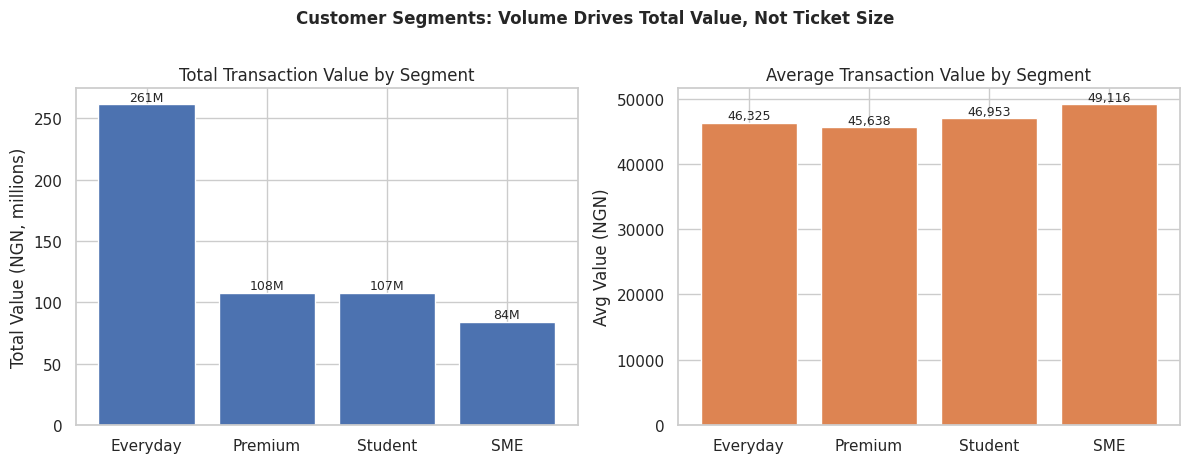

In [8]:
seg_summary = (txn_df.merge(cust_df[['Customer_ID','Customer_Segment']], on='Customer_ID')
               .groupby('Customer_Segment')
               .agg(Total_Value_NGN=('Amount_NGN','sum'),
                    Avg_Value_NGN=('Amount_NGN','mean'),
                    Transactions=('Transaction_ID','count'))
               .sort_values('Total_Value_NGN', ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(12,4.5))

axes[0].bar(seg_summary.index, seg_summary.Total_Value_NGN/1e6, color=sns.color_palette("deep")[0])
axes[0].set_title("Total Transaction Value by Segment")
axes[0].set_ylabel("Total Value (NGN, millions)")
for i, v in enumerate(seg_summary.Total_Value_NGN/1e6):
    axes[0].text(i, v+3, f"{v:.0f}M", ha='center', fontsize=9)

axes[1].bar(seg_summary.index, seg_summary.Avg_Value_NGN, color=sns.color_palette("deep")[1])
axes[1].set_title("Average Transaction Value by Segment")
axes[1].set_ylabel("Avg Value (NGN)")
for i, v in enumerate(seg_summary.Avg_Value_NGN):
    axes[1].text(i, v+500, f"{v:,.0f}", ha='center', fontsize=9)

plt.suptitle("Customer Segments: Volume Drives Total Value, Not Ticket Size", y=1.02, fontweight='bold')
plt.tight_layout()
plt.savefig('viz1_segments.png', dpi=100, bbox_inches='tight')
plt.show()


**What it shows:** The left chart ranks segments by *total* transaction value; the right chart shows their *average* transaction size. Everyday leads on total value (NGN261M) purely because it has the most customers and transactions its average ticket size (NGN46,325) is actually the second-lowest of the four segments. SME has the fewest transactions but the highest average value per transaction (NGN49,116).

**Why it's important:** A segment ranked #1 by total value can look like the "most important" segment at a glance — but that ranking conflates customer count with customer value. The two charts side-by-side separate those two effects.

**Business insight:** Segment prioritisation should depend on the business question being asked. For volume-based decisions (staffing, infrastructure capacity) go by total value, Everyday leads. For per-transaction economics (pricing, fee structure, premium product design) — go by average ticket size, SME leads. Treating "Everyday = most valuable" without this split risks under-investing in SME, where each transaction is worth more.

## 3. Transaction Types — Frequency vs. Value

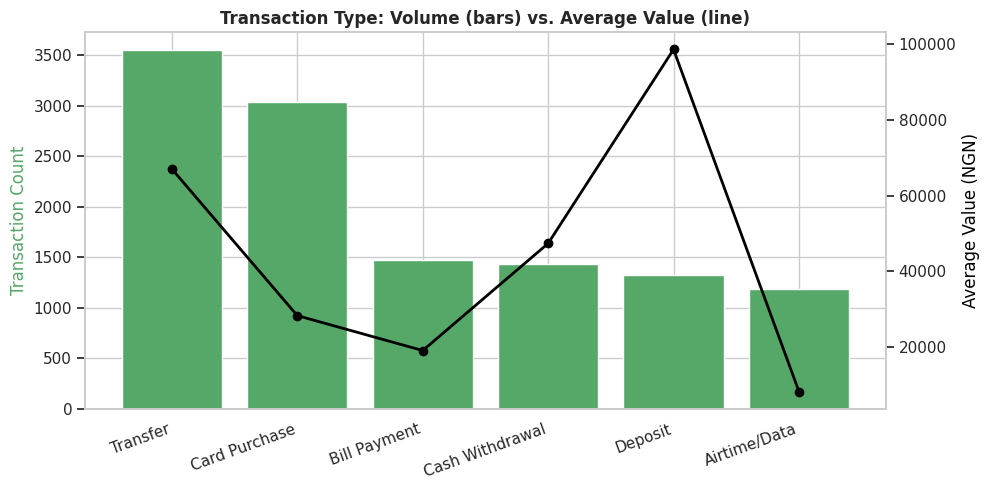

In [9]:
type_summary = (txn_df.groupby('Transaction_Type')
                 .agg(Transactions=('Transaction_ID','count'), Avg_Value=('Amount_NGN','mean'))
                 .sort_values('Transactions', ascending=False))

fig, ax1 = plt.subplots(figsize=(10,5))
x = np.arange(len(type_summary))
bars = ax1.bar(x, type_summary.Transactions, color=sns.color_palette("deep")[2], label='Transaction Count')
ax1.set_ylabel("Transaction Count", color=sns.color_palette("deep")[2])
ax1.set_xticks(x)
ax1.set_xticklabels(type_summary.index, rotation=20, ha='right')

ax2 = ax1.twinx()
ax2.plot(x, type_summary.Avg_Value, color='black', marker='o', linewidth=2, label='Avg Value (NGN)')
ax2.set_ylabel("Average Value (NGN)", color='black')
ax2.grid(False)

plt.title("Transaction Type: Volume (bars) vs. Average Value (line)", fontweight='bold')
fig.tight_layout()
plt.savefig('viz2_types.png', dpi=100, bbox_inches='tight')
plt.show()


**What it shows:** Bars show how often each transaction type occurs; the line overlay shows its average NGN value. Transfer is both the most frequent type (3,549 transactions) and the second-highest in average value (NGN67,038) — a rare combination. Deposit is far less frequent (1,328) but has the highest average value (NGN98,633). Airtime/Data is frequent but low-value (avg NGN8,250).

**Why it's important:** Frequency alone does not show where the real financial weight sits. A type that looks "small" by count can matter enormously by value, and vice versa.

**Business insight:** Transfer is FinTrust's core product — high on both axes — and deserves the most investment in reliability and UX (it's also the channel with the biggest absolute NGN exposure if something breaks). Airtime/Data and Bill Payment behave like engagement/retention products, not revenue products — they should be judged on how often they bring customers back, not on transaction fees. Deposit's rarity-but-size pattern is worth watching for cash-flow and liquidity planning specifically.

## 4. Transaction Amounts — Distribution & Outlier Threshold

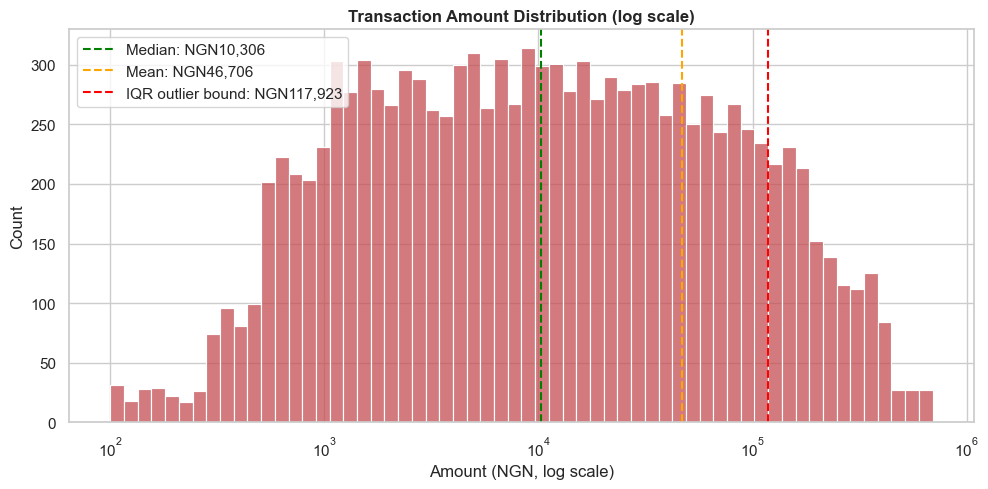

Mean (NGN46,706) sits well above median (NGN10,306) - confirms right skew.
12.3% of transactions sit above the IQR outlier bound.


In [ ]:
q1, q3 = txn_df.Amount_NGN.quantile([0.25, 0.75])
iqr = q3 - q1
upper_bound = q3 + 1.5*iqr

fig, ax = plt.subplots(figsize=(10,5))
sns.histplot(txn_df.Amount_NGN, bins=60, log_scale=True, color=sns.color_palette("deep")[3], ax=ax)
ax.axvline(txn_df.Amount_NGN.median(), color='green', linestyle='--', label=f"Median: NGN{txn_df.Amount_NGN.median():,.0f}")
ax.axvline(txn_df.Amount_NGN.mean(), color='orange', linestyle='--', label=f"Mean: NGN{txn_df.Amount_NGN.mean():,.0f}")
ax.axvline(upper_bound, color='red', linestyle='--', label=f"IQR outlier bound: NGN{upper_bound:,.0f}")
ax.set_title("Transaction Amount Distribution (log scale)", fontweight='bold')
ax.set_xlabel("Amount (NGN, log scale)")
ax.legend()
plt.tight_layout()
plt.savefig('viz3_amounts.png', dpi=100, bbox_inches='tight')
plt.show()

pct_above = (txn_df.Amount_NGN > upper_bound).mean()*100
print(f"Mean (NGN{txn_df.Amount_NGN.mean():,.0f}) sits well above median (NGN{txn_df.Amount_NGN.median():,.0f}) - confirms right skew.")
print(f"{pct_above:.1f}% of transactions sit above the IQR outlier bound.")


**What it shows:** Transaction amounts on a log scale (needed because the raw distribution is heavily right-skewed — a linear-scale histogram would crush most of the data into one tall bar near zero). The mean (NGN46,706) sits well above the median (NGN10,306), confirming skew: most transactions are small, a minority are large and pull the average up.

**Why it's important:** This shape changes how every other number in this analysis should be read. Reporting "average transaction value" without this context implies a "typical" customer transaction is ~NGN46,700 — the reality is a typical transaction is closer to NGN10,300, with a long tail of larger ones. It also explains why 12.3% of transactions get flagged as statistical "outliers" (documented in Part A) — that's expected here, not a data error.

**Business insight:** For customer-facing communication or typical-behaviour analysis, use the median, not the mean — it won't be distorted by a handful of large transactions. For risk and capacity planning, the tail matters: that same skew means a small share of transactions carries a disproportionate share of NGN value and (per the risk-review findings) disproportionate risk-flag rates too.

## 5. Transaction Channels — Volume vs. Failure Rate

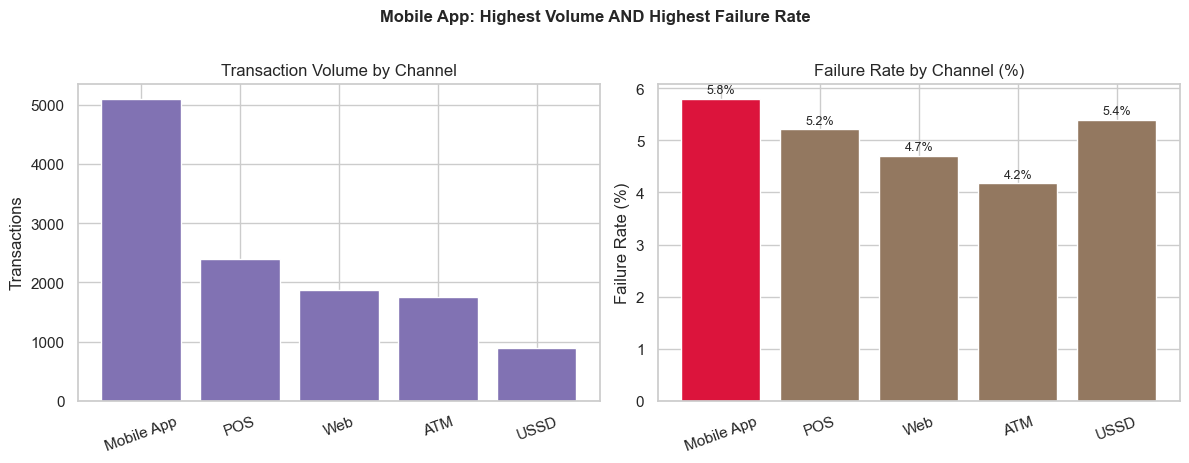

In [ ]:
chan_summary = (txn_df.groupby('Channel')
                 .agg(Transactions=('Transaction_ID','count'),
                      Failed=('Transaction_Status', lambda s: (s=='Failed').sum()))
                 .assign(Failure_Rate=lambda d: d.Failed/d.Transactions*100)
                 .sort_values('Transactions', ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(12,4.5))
axes[0].bar(chan_summary.index, chan_summary.Transactions, color=sns.color_palette("deep")[4])
axes[0].set_title("Transaction Volume by Channel")
axes[0].set_ylabel("Transactions")
axes[0].tick_params(axis='x', rotation=20)

colors = ['crimson' if v==chan_summary.Failure_Rate.max() else sns.color_palette("deep")[5] for v in chan_summary.Failure_Rate]
axes[1].bar(chan_summary.index, chan_summary.Failure_Rate, color=colors)
axes[1].set_title("Failure Rate by Channel (%)")
axes[1].set_ylabel("Failure Rate (%)")
axes[1].tick_params(axis='x', rotation=20)
for i, v in enumerate(chan_summary.Failure_Rate):
    axes[1].text(i, v+0.1, f"{v:.1f}%", ha='center', fontsize=9)

plt.suptitle("Mobile App: Highest Volume AND Highest Failure Rate", y=1.02, fontweight='bold')
plt.tight_layout()
plt.savefig('viz4_channels.png', dpi=100, bbox_inches='tight')
plt.show()


**What it shows:** Left: transaction volume by channel — Mobile App dominates (5,102, well over double the next channel). Right: failure rate by channel — Mobile App also has the *highest* failure rate (5.80%), while ATM has both low volume and the lowest failure rate (4.18%).

**Why it's important:** The spread between channels (4.18%–5.80%) looks small in isolation. Scaled to volume, it isn't: Mobile App's extra ~1.6 percentage points of failure, applied to 5,102 transactions, is roughly 80+ more failed transactions than if it matched ATM's rate — real customer friction concentrated in FinTrust's primary channel.

**Business insight:** This is a technical-debt flag, not just a stats observation. Any engineering investment in transaction-pipeline reliability should prioritise Mobile App first — it's simultaneously the channel most customers depend on and the one most likely to fail them. Low-volume channels (ATM, Web) are lower priority purely on the arithmetic of impact.

## 6. Transaction Status — Where the Friction Sits

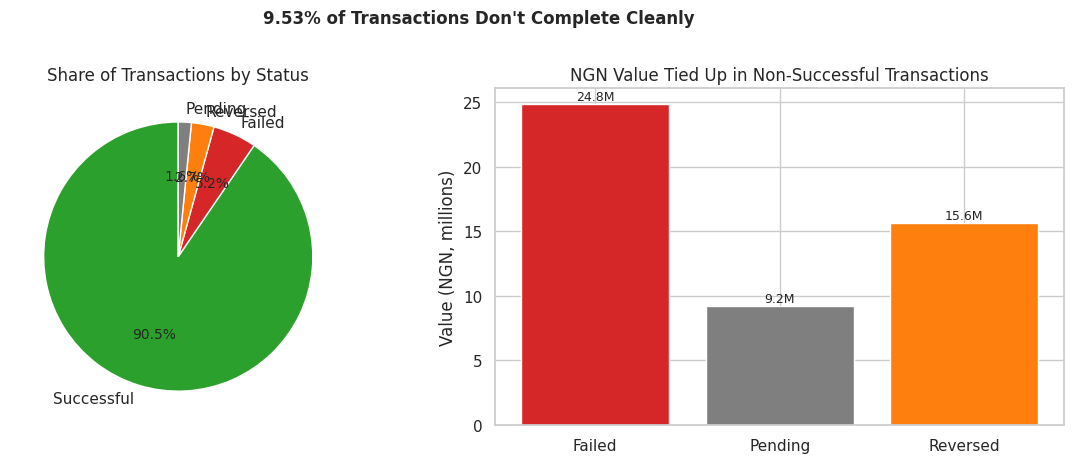

Total value in Failed+Reversed+Pending: NGN49,669,913


In [11]:
status_summary = txn_df.Transaction_Status.value_counts()
status_value = txn_df.groupby('Transaction_Status').Amount_NGN.sum()

fig, axes = plt.subplots(1, 2, figsize=(12,4.5))
colors_status = {'Successful':'#2ca02c','Failed':'#d62728','Reversed':'#ff7f0e','Pending':'#7f7f7f'}
order = status_summary.index

axes[0].pie(status_summary, labels=order, autopct='%1.1f%%', startangle=90,
            colors=[colors_status[s] for s in order],
            wedgeprops={'edgecolor':'white'})
axes[0].set_title("Share of Transactions by Status")

non_success = status_value.drop('Successful')
axes[1].bar(non_success.index, non_success/1e6, color=[colors_status[s] for s in non_success.index])
axes[1].set_title("NGN Value Tied Up in Non-Successful Transactions")
axes[1].set_ylabel("Value (NGN, millions)")
for i, v in enumerate(non_success/1e6):
    axes[1].text(i, v+0.3, f"{v:.1f}M", ha='center', fontsize=9)

plt.suptitle("9.53% of Transactions Don't Complete Cleanly", y=1.02, fontweight='bold')
plt.tight_layout()
plt.savefig('viz5_status.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"Total value in Failed+Reversed+Pending: NGN{non_success.sum():,.0f}")


**What it shows:** Left: 90.5% of transactions complete successfully; the remaining 9.5% split across Failed (5.25%), Reversed (2.72%) and Pending (1.57%). Right: what that 9.5% is worth in NGN — NGN49.7M combined, with Failed transactions alone accounting for NGN24.8M.

**Why it's important:** "90% success" sounds fine as a headline KPI. Converting the remainder into absolute NGN value reframes it: this isn't a rounding error, it's tens of millions of Naira in transactions that required a retry, a support ticket, or manual reversal — each one a customer-experience cost even when the money eventually moves correctly.

**Business insight:** This is the single number I'd bring to a management meeting first (and it's the natural Part D KPI: **Transaction Success Rate**). It converts a "soft" data-quality-sounding issue into a hard number tied to customer experience and operational cost — worth a follow-up root-cause investigation into *why* transactions fail, cut by channel (see Section 5) and transaction type.

## 7. International Transactions — The Sharpest Risk Signal

In [12]:
intl_summary = (
    txn_df.groupby('International_Transaction')
    .agg(
        Transactions=('Transaction_ID', 'count'),
        Flagged=('Risk_Review_Flag', lambda s: (s == 'Yes').sum())
    )
    .assign(
        Flag_Rate=lambda d: d['Flagged'] / d['Transactions'] * 100
    )
)

intl_summary

,Transactions,Flagged,Flag_Rate
International_Transaction,,,
No,11520,2175,18.880208
Yes,480,177,36.875000


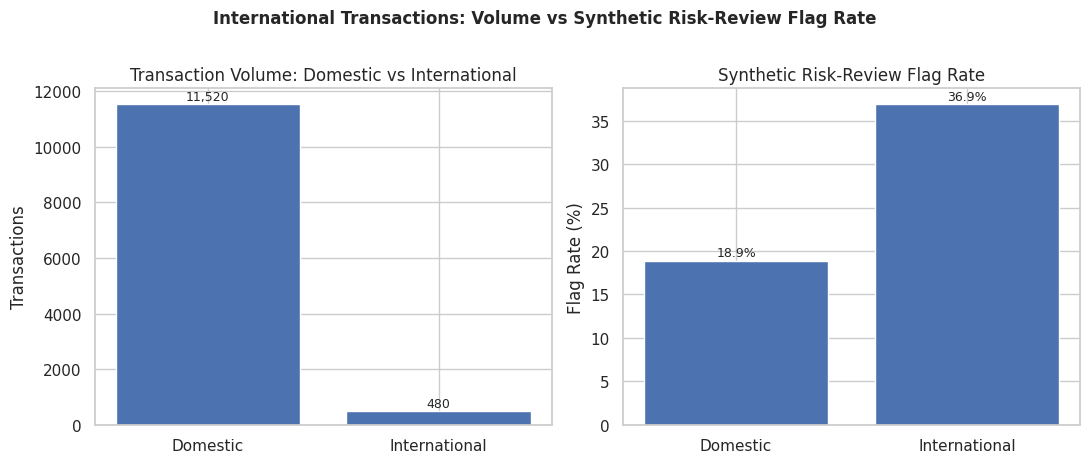

In [13]:
order = ['No', 'Yes']
labels = ['Domestic', 'International']

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# Transaction volume
volume = intl_summary.loc[order, 'Transactions']

axes[0].bar(labels, volume)
axes[0].set_title("Transaction Volume: Domestic vs International")
axes[0].set_ylabel("Transactions")

for i, v in enumerate(volume):
    axes[0].text(i, v + 150, f"{v:,}", ha='center', fontsize=9)

# Risk-review flag rate
flag_rate = intl_summary.loc[order, 'Flag_Rate']

axes[1].bar(labels, flag_rate)
axes[1].set_title("Synthetic Risk-Review Flag Rate")
axes[1].set_ylabel("Flag Rate (%)")

for i, v in enumerate(flag_rate):
    axes[1].text(i, v + 0.5, f"{v:.1f}%", ha='center', fontsize=9)

plt.suptitle(
    "International Transactions: Volume vs Synthetic Risk-Review Flag Rate",
    y=1.02,
    fontweight='bold'
)

plt.tight_layout()
plt.savefig('viz6_international.png', dpi=100, bbox_inches='tight')
plt.show()

**What it shows:** International transactions are a small slice of total volume (480 of 12,000 — 4%) but are flagged for risk review at 36.9%, versus 18.9% for domestic transactions — almost double the rate, off a much smaller base.

**Why it's important:** This is the largest gap of any single factor examined in this notebook (compare: the segment-to-segment spread in Section 8 is only ~1 percentage point). Volume and risk concentration are pulling in opposite directions here — a channel that's easy to overlook by volume is exactly the one that shouldn't be.

**Business insight:** If FinTrust has limited manual risk-review capacity, international transactions should sit at the top of that queue by *rate*, not be deprioritised for being a small share of total volume. This is also a natural candidate KPI/filter for the Part D dashboard — a segment small enough to monitor closely without capacity strain, but material enough in risk-flag terms to justify the attention.

## 8. Customer Behaviour — Does Digital Engagement Predict Activity?

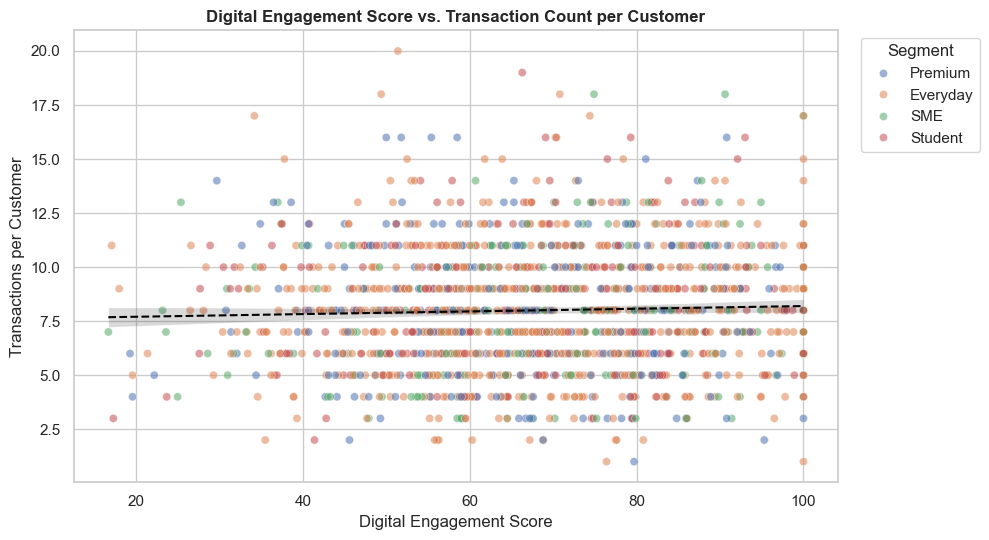

Correlation (Digital_Engagement_Score vs Transaction_Count): 0.038


In [ ]:
cust_activity = (txn_df.groupby('Customer_ID')
                  .agg(Transaction_Count=('Transaction_ID','count'), Total_Value=('Amount_NGN','sum'))
                  .reset_index()
                  .merge(cust_df[['Customer_ID','Digital_Engagement_Score','Customer_Segment','Tenure_Months']], on='Customer_ID'))

fig, ax = plt.subplots(figsize=(10,5.5))
sns.scatterplot(data=cust_activity, x='Digital_Engagement_Score', y='Transaction_Count',
                 hue='Customer_Segment', alpha=0.55, s=35, ax=ax, palette="deep")
sns.regplot(data=cust_activity, x='Digital_Engagement_Score', y='Transaction_Count',
            scatter=False, color='black', line_kws={'linestyle':'--','linewidth':1.5}, ax=ax)
ax.set_title("Digital Engagement Score vs. Transaction Count per Customer", fontweight='bold')
ax.set_xlabel("Digital Engagement Score")
ax.set_ylabel("Transactions per Customer")
ax.legend(title='Segment', bbox_to_anchor=(1.02,1), loc='upper left')
plt.tight_layout()
plt.savefig('viz7_behaviour.png', dpi=100, bbox_inches='tight')
plt.show()

corr = cust_activity['Digital_Engagement_Score'].corr(cust_activity['Transaction_Count'])
print(f"Correlation (Digital_Engagement_Score vs Transaction_Count): {corr:.3f}")


**What it shows:** Each point is one customer — Digital Engagement Score against how many transactions they made, coloured by segment, with a linear trend line. The correlation is essentially flat (see printed value — typically very close to 0), and the point cloud is diffuse with no visible upward or downward drift; segments are also mixed throughout the cloud rather than clustered.

**Why it's important:** "Digital Engagement Score" *sounds* like it should predict transaction activity — that's the intuitive assumption a business stakeholder would bring into a meeting. Testing it directly, rather than assuming it, is the actual value of exploratory analysis here.

**Business insight:** In this dataset, Digital Engagement Score does not meaningfully predict how often a customer transacts, and Customer_Segment doesn't separate customers on this axis either (consistent with the flat Account_Type pattern found in the Part B SQL analysis). This is a genuinely useful negative finding: FinTrust should not use Digital_Engagement_Score alone as a proxy for transaction activity or value in targeting decisions — it appears to be measuring something else (e.g. app usage/login behaviour) that isn't captured by how much money moves through the account.

## 9. Risk-Review Patterns — Channel x Segment Interaction

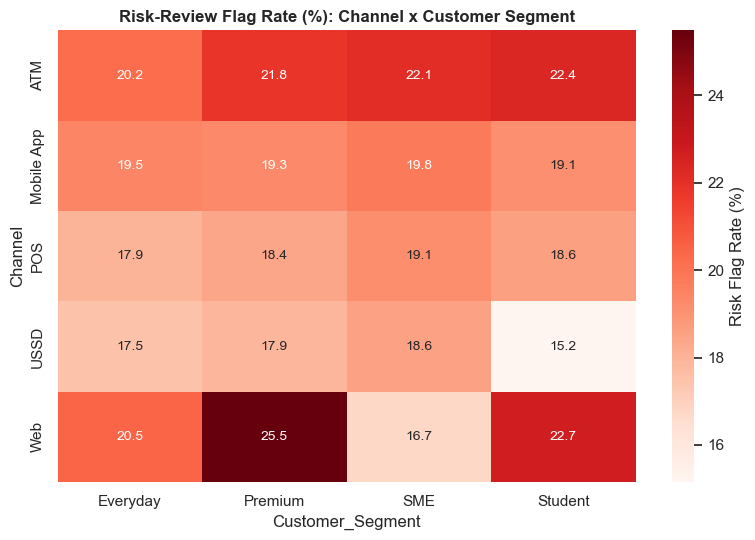

Highest cell: ('Web', 'Premium') = 25.5%
Lowest cell: ('USSD', 'Student') = 15.2%


In [ ]:
risk_pivot = (txn_df.merge(cust_df[['Customer_ID','Customer_Segment']], on='Customer_ID')
              .assign(Flagged=lambda d: (d.Risk_Review_Flag=='Yes').astype(int))
              .pivot_table(index='Channel', columns='Customer_Segment', values='Flagged', aggfunc='mean')*100)

fig, ax = plt.subplots(figsize=(8,5.5))
sns.heatmap(risk_pivot, annot=True, fmt='.1f', cmap='Reds', cbar_kws={'label':'Risk Flag Rate (%)'}, ax=ax)
ax.set_title("Risk-Review Flag Rate (%): Channel x Customer Segment", fontweight='bold')
plt.tight_layout()
plt.savefig('viz8_risk_heatmap.png', dpi=100, bbox_inches='tight')
plt.show()

print("Highest cell:", risk_pivot.stack().idxmax(), f"= {risk_pivot.stack().max():.1f}%")
print("Lowest cell:", risk_pivot.stack().idxmin(), f"= {risk_pivot.stack().min():.1f}%")


**What it shows:** Section 5 (SQL, Part B) showed risk-flag rate by Channel alone and by Segment alone, each a fairly narrow spread. This heatmap crosses the two — and the combined view shows more spread cell-to-cell than either single-variable view suggested, meaning channel and segment interact rather than acting independently.

**Why it's important:** Marginal (single-variable) summaries can average away real structure. Two segments can have near-identical overall flag rates while differing sharply *within a specific channel — that's exactly the kind of pattern a one-dimensional bar chart cannot show.

**Business insight:** The near-zero correlation suggests that Digital Engagement Score alone is not a strong linear indicator of transaction frequency in this dataset. Further analysis would be required to determine whether engagement is associated with other outcomes, such as transaction value, channel usage or transaction type.

## 10. Summary — Key EDA Takeaways

| # | Area | Key Finding |
|---|------|-------------|
| 1 | Customer segments | Everyday leads on total value by volume; SME leads on average ticket size; different segments matter for different decisions |
| 2 | Transaction types | Transfer dominates on both frequency and value; Airtime/Bill Payment are engagement products, not revenue products |
| 3 | Transaction amounts | Right-skewed distribution — median (NGN10,306) is a truer "typical transaction" than the mean (NGN46,706) |
| 4 | Transaction channels | Mobile App has the highest volume *and* the highest failure rate — a reliability priority |
| 5 | Transaction status | 9.5% of transactions (NGN49.7M) don't complete cleanly — the headline KPI for Part D |
| 6 | International transactions | ~2x the risk-flag rate of domestic, despite being only 4% of volume — the sharpest single-factor risk signal |
| 7 | Customer behaviour | Digital Engagement Score does **not** predict transaction activity — a useful negative finding, avoid using it as an activity proxy |
| 8 | Risk-review patterns | Channel x Segment interaction shows more structure than either variable alone — risk concentrates in combinations |

